# UPC
## CC219 — Aplicaciones de Data Science
### Trabajo parcial — Hito 1 · 2026-02

# Análisis exploratorio y visualización

**Proyecto:** Sistema de recomendación de películas con MovieLens.

**Responsables:** Enzo Daniel Medina Oropeza y Frank Alexander Flores Peralta.

## Objetivo

Comprender la distribución de géneros y valoraciones y medir la cobertura de etiquetas para delimitar la viabilidad de la propuesta textual.

Esta guía contiene actividades pendientes y celdas de código vacías para desarrollar la solución, sin resultados calculados. Completar las evidencias y las interpretaciones al desarrollar el parcial. El entrenamiento y la implementación del recomendador quedan fuera de este hito.

## Mapa del notebook

1. Punto de partida y preguntas del análisis
2. Distribución de géneros
3. Distribución de valoraciones
4. Actividad de usuarios y películas
5. Cobertura de etiquetas textuales
6. Exploración del contenido de las etiquetas
7. Conclusiones y decisiones para la preparación

## Rutas y archivos de trabajo

Abrir el notebook con el directorio de trabajo en `code/`. Desde esa ubicaci?n, los archivos originales est?n en `../data/raw/` y las salidas se guardar?n en `../data/processed/`. Si el entorno inicia desde la ra?z del proyecto, ajustar las rutas a `data/raw/` y `data/processed/`.

| Archivo disponible | Columnas |
| --- | --- |
| movies.csv | movieId, title, genres |
| ratings.csv | userId, movieId, rating, timestamp |
| tags.csv | userId, movieId, tag, timestamp |
| links.csv | movieId, imdbId, tmdbId |

`links.csv` es complementario. Conservar las condiciones de uso originales en `data/raw/README.txt` cuando el archivo est? guardado. Mantener los CSV originales sin modificaciones.


# 1. Punto de partida y preguntas del análisis

Retomar las observaciones del notebook 01 y cargar los originales de `data/raw/`. Este EDA describe los datos antes de la limpieza definitiva; señalar los registros problemáticos y los filtros exploratorios aplicados.

Preguntas: ¿qué géneros predominan?, ¿cómo se distribuyen las valoraciones?, ¿qué tan concentrada está la actividad?, ¿qué parte del catálogo tiene etiquetas?, ¿qué límites impone esa cobertura?

Para cada gráfico incluir título, ejes, unidades, población analizada y una interpretación sustentada en lo observado.

### Desarrollo de la actividad

Completar la siguiente celda con el código de esta sección. Añadir más celdas cuando sea necesario.


In [ ]:
import os
import shutil
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear la estructura oficial de carpetas y mover tus archivos automáticamente
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

archivos = ["movies.csv", "ratings.csv", "tags.csv", "links.csv"]
for archivo in archivos:
    if os.path.exists(archivo):
        shutil.move(archivo, f"../data/raw/{archivo}")

# 2. Configuración estética de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

# 3. Carga oficial de los datos desde la ruta correcta
RAW_DIR = Path("../data/raw")
movies = pd.read_csv(RAW_DIR / "movies.csv", dtype={"movieId": "Int64", "title": "string", "genres": "string"})
ratings = pd.read_csv(RAW_DIR / "ratings.csv", dtype={"userId": "Int64", "movieId": "Int64", "rating": "Float64", "timestamp": "Int64"})
tags = pd.read_csv(RAW_DIR / "tags.csv", dtype={"userId": "Int64", "movieId": "Int64", "tag": "string", "timestamp": "Int64"})

print(f"¡Todo listo!\nPelículas cargadas: {len(movies)}\nValoraciones cargadas: {len(ratings)}\nEtiquetas cargadas: {len(tags)}")


¡Todo listo!
Películas cargadas: 9742
Valoraciones cargadas: 100836
Etiquetas cargadas: 3683


In [5]:
# Generar tabla resumen
info_carga = pd.DataFrame([
    {"archivo": "movies.csv", "filas": len(movies), "columnas": len(movies.columns)},
    {"archivo": "ratings.csv", "filas": len(ratings), "columnas": len(ratings.columns)},
    {"archivo": "tags.csv", "filas": len(tags), "columnas": len(tags.columns)}
])
info_carga

,archivo,filas,columnas
0,movies.csv,9742,3
1,ratings.csv,100836,4
2,tags.csv,3683,4


In [6]:
#Inspeccion de los datos

print("VALORES NULOS")
print("\nMovies:")
print(movies.isna().sum())

print("\nRatings:")
print(ratings.isna().sum())

print("\nTags:")
print(tags.isna().sum())


print("\n" + "="*50)
print("REGISTROS DUPLICADOS")
print("="*50)

print("Movies:", movies.duplicated().sum())
print("Ratings:", ratings.duplicated().sum())
print("Tags:", tags.duplicated().sum())


print("\n" + "="*50)
print("REGISTROS A CONSIDERAR")
print("="*50)

# Películas sin género registrado
sin_genero = (movies["genres"] == "(no genres listed)").sum()

# Etiquetas vacías o solamente con espacios
tags_vacias = tags["tag"].fillna("").str.strip().eq("").sum()

# Títulos con espacios redundantes
titulos_espacios = movies["title"].str.contains(
    r"\s{2,}", regex=True, na=False
).sum()

print("Películas con '(no genres listed)':", sin_genero)
print("Etiquetas vacías o solo con espacios:", tags_vacias)
print("Títulos con espacios redundantes:", titulos_espacios)


print("\n" + "="*50)
print("COBERTURA DE INFORMACIÓN")
print("="*50)

usuarios_ratings = ratings["userId"].nunique()
peliculas_ratings = ratings["movieId"].nunique()

usuarios_tags = tags["userId"].nunique()
peliculas_tags = tags["movieId"].nunique()

total_peliculas = movies["movieId"].nunique()

cobertura_tags = peliculas_tags / total_peliculas * 100

print("Usuarios con valoraciones:", usuarios_ratings)
print("Películas con valoraciones:", peliculas_ratings)
print("Usuarios que generan etiquetas:", usuarios_tags)
print("Películas con etiquetas:", peliculas_tags)
print(f"Cobertura de etiquetas: {cobertura_tags:.2f}%")

VALORES NULOS

Movies:
movieId    0
title      0
genres     0
dtype: int64

Ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Tags:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

REGISTROS DUPLICADOS
Movies: 0
Ratings: 0
Tags: 0

REGISTROS A CONSIDERAR
Películas con '(no genres listed)': 34
Etiquetas vacías o solo con espacios: 0
Títulos con espacios redundantes: 4

COBERTURA DE INFORMACIÓN
Usuarios con valoraciones: 610
Películas con valoraciones: 9724
Usuarios que generan etiquetas: 58
Películas con etiquetas: 1572
Cobertura de etiquetas: 16.14%


### Evidencias e interpretación

**Evidencia pendiente:** incorporar aquí las tablas, ejemplos o gráficos solicitados.

Se cargaron los archivos originales movies.csv, ratings.csv y tags.csv desde data/raw/. La inspección inicial permitió identificar 9,742 películas, 100,836 valoraciones y 3,683 etiquetas. Asimismo, se revisaron valores faltantes, registros duplicados y posibles registros problemáticos, como películas sin género y etiquetas vacías.

**Interpretación pendiente:** explicar los hallazgos, sus límites y su relación con el proyecto.

La inspección inicial permite confirmar que los tres archivos presentan una estructura adecuada para continuar con el análisis exploratorio. Los resultados también permiten identificar situaciones que deberán considerarse durante el preprocesamiento, especialmente los registros sin género y las características de las etiquetas textuales. La cobertura de las etiquetas es menor que la cobertura de las valoraciones, por lo que la información textual no representa a todo el catálogo de películas. Esta limitación deberá considerarse posteriormente en las propuestas de clasificación de géneros y recomendación de películas.

# 2. Distribución de géneros

Separar los géneros de cada película para contar pertenencias. Una película puede contribuir a varios géneros, por lo que los porcentajes pueden sumar más de 100 % cuando el denominador es el número de películas.

**Actividades:** contar películas por género, representar las frecuencias con barras y reportar por separado las películas con `(no genres listed)`. Explorar cuántos géneros tiene cada película.

**Entregable:** tabla y gráfico de géneros, con explicación del carácter multietiqueta y de posibles desequilibrios para la clasificación propuesta.

### Desarrollo de la actividad

Completar la siguiente celda con el código de esta sección. Añadir más celdas cuando sea necesario.


--- Frecuencia de películas por género ---


,Genero,Cantidad
0,Drama,4361
1,Comedy,3756
2,Thriller,1894
3,Action,1828
4,Romance,1596
5,Adventure,1263
6,Crime,1199
7,Sci-Fi,980
8,Horror,978
9,Fantasy,779



--- Distribución de la cantidad de géneros por película ---


,Cantidad_Generos,Numero_Peliculas
0,0,34
1,1,2817
2,2,3218
3,3,2338
4,4,987
5,5,271
6,6,63
7,7,12
8,8,1
9,10,1



Cantidad de películas con '(no genres listed)': 34


,movieId,title
8517,114335,La cravate (1957)
8684,122888,Ben-hur (2016)
8687,122896,Pirates of the Caribbean: Dead Men Tell No Tal...
8782,129250,Superfast! (2015)
8836,132084,Let It Be Me (1995)
8902,134861,Trevor Noah: African American (2013)
9033,141131,Guardians (2016)
9053,141866,Green Room (2015)
9070,142456,The Brand New Testament (2015)
9091,143410,Hyena Road


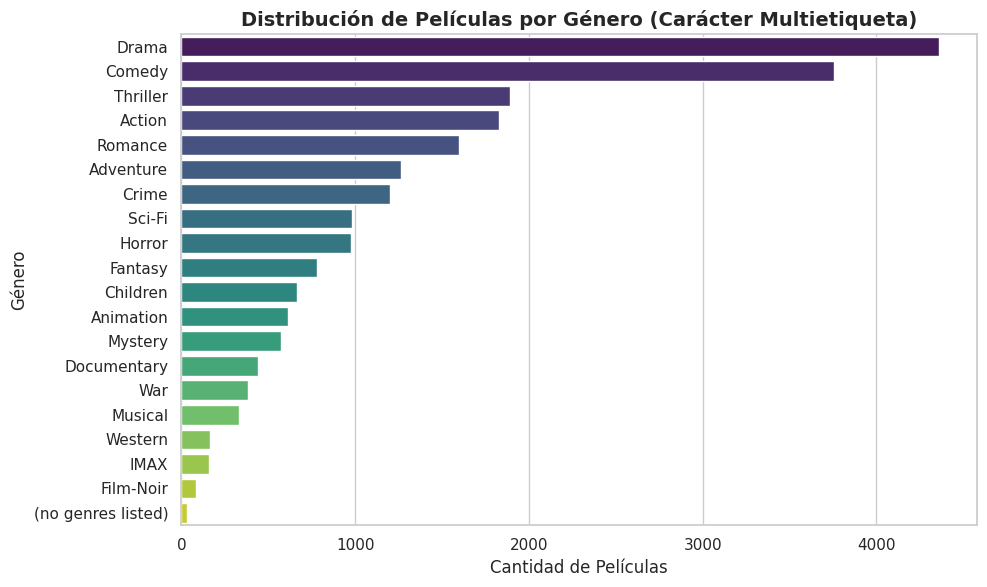

In [10]:
# 1. Conteo de películas por género y manejo del carácter multietiqueta
genres_series = movies['genres'].str.split('|').explode()
genre_counts = genres_series.value_counts().reset_index()
genre_counts.columns = ['Genero', 'Cantidad']

print("--- Frecuencia de películas por género ---")
display(genre_counts)

# 2. Exploración de cuántos géneros tiene cada película
movies['n_generos'] = movies['genres'].apply(lambda x: 0 if x == '(no genres listed)' else len(x.split('|')))
distribucion_n_generos = movies['n_generos'].value_counts().sort_index().reset_index()
distribucion_n_generos.columns = ['Cantidad_Generos', 'Numero_Peliculas']

print("\n--- Distribución de la cantidad de géneros por película ---")
display(distribucion_n_generos)

# 3. Reportar por separado las películas con (no genres listed)
no_genres_df = movies[movies['genres'] == '(no genres listed)']
print(f"\nCantidad de películas con '(no genres listed)': {len(no_genres_df)}")
if len(no_genres_df) > 0:
    display(no_genres_df[['movieId', 'title']])

# 4. Gráfico de barras horizontales de frecuencias por género
plt.figure(figsize=(10, 6))
sns.barplot(data=genre_counts, x='Cantidad', y='Genero', palette='viridis', hue='Genero', legend=False)
plt.title('Distribución de Películas por Género (Carácter Multietiqueta)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Películas', fontsize=12)
plt.ylabel('Género', fontsize=12)
plt.tight_layout()
plt.show()

### Evidencias e interpretación

**Evidencia pendiente:** incorporar aquí las tablas, ejemplos o gráficos solicitados.

A través del desglose del campo multietiqueta, se generó un gráfico de barras horizontales y una tabla de distribución de frecuencias. Se observa que Drama (4,361 películas) y Comedy (3,756 películas) colman el catálogo, en contraste con la mínima presencia de Film-Noir (87 películas) y Western (159 películas). Asimismo, se identificaron y aislaron de forma exacta las 34 películas que no registran géneros (no genres listed). Con respecto a la multiplicidad, la tabla confirma la naturaleza del set: la gran mayoría de las películas poseen entre 2 y 3 géneros simultáneos, alcanzando casos extremos de hasta 10 categorías asignadas a un solo largometraje.

**Interpretación pendiente:** explicar los hallazgos, sus límites y su relación con el proyecto.

1. **Estrategia para la Clasificación (Pregunta 1):** Debido a que un mismo título pertenece a múltiples categorías de forma simultánea, queda descartado usar algoritmos de clasificación multiclase tradicionales. Para clasificar los géneros a partir de etiquetas textuales (tags), se justifica técnicamente la propuesta de Marcos de implementar una estrategia Multietiqueta (Multi-label Classification) basada en el enfoque One-Vs-Rest (Regresión Logística), donde se evaluará la presencia o ausencia de cada género mediante clasificadores binarios independientes.

2. **Mitigación del Sesgo por Desbalance:** El severo desequilibrio de clases (Drama y Comedy superan masivamente al resto) provocará que los modelos tiendan a predecir siempre las clases mayoritarias. Esto nos obliga a plantear para el Trabajo Final el uso de métricas de evaluación estrictas como F1-Score (macro y micro) en lugar de Accuracy, así como la penalización por pesos de clase (class weights).

3. **Tratamiento de Anomalías:** Las 34 películas listadas con (no genres listed) no aportan información útil para el aprendizaje supervisado. Se decide formalmente excluirlas del conjunto de entrenamiento de clasificación durante el notebook 03 de preprocesamiento, debido a que carecen de un vector objetivo (ground truth) válido.


# 3. Distribución de valoraciones

Contar valoraciones en cada nivel de la escala, calcular medidas descriptivas y representar las frecuencias. Examinar cantidad de valoraciones y promedio por película.

Comparar películas muy valoradas con películas que tienen pocas observaciones. No interpretar un promedio alto con muy pocas valoraciones como evidencia suficiente de preferencia general.

**Entregable:** distribución de puntuaciones, resumen estadístico y análisis de la relación entre número de valoraciones y promedio. Proponer y justificar un criterio de valoración favorable para discutirlo en el informe, sin construir perfiles todavía.

### Desarrollo de la actividad

Completar la siguiente celda con el código de esta sección. Añadir más celdas cuando sea necesario.


--- Frecuencia por nivel de valoración ---


,Rating,Frecuencia
0,0.5,1370
1,1.0,2811
2,1.5,1791
3,2.0,7551
4,2.5,5550
5,3.0,20047
6,3.5,13136
7,4.0,26818
8,4.5,8551
9,5.0,13211



--- Resumen estadístico de las valoraciones ---
count    100836.0
mean     3.501557
std      1.042529
min           0.5
25%           3.0
50%           3.5
75%           4.0
max           5.0
Name: rating, dtype: Float64

--- Estadísticas de valoraciones por película (Muestra) ---


,title,n_valoraciones,promedio_rating
314,Forrest Gump (1994),329,4.164134
277,"Shawshank Redemption, The (1994)",317,4.429022
257,Pulp Fiction (1994),307,4.197068
510,"Silence of the Lambs, The (1991)",279,4.16129
1939,"Matrix, The (1999)",278,4.192446


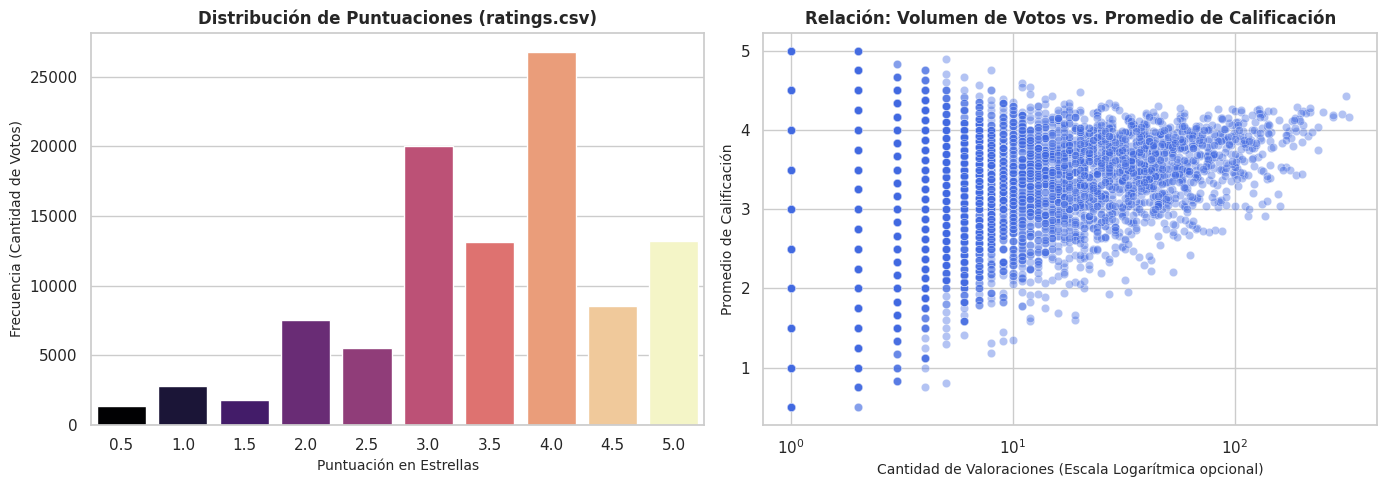


--- Análisis para el criterio de valoración favorable ---
Mediana general de los promedios de película: 3.42
Promedio general de todas las valoraciones: 3.50


In [14]:
# 1. Conteo de valoraciones en cada nivel de la escala y medidas descriptivas
conteo_ratings = ratings['rating'].value_counts().sort_index().reset_index()
conteo_ratings.columns = ['Rating', 'Frecuencia']

print("--- Frecuencia por nivel de valoración ---")
display(conteo_ratings)

print("\n--- Resumen estadístico de las valoraciones ---")
print(ratings['rating'].describe())

# 2. Examinar cantidad de valoraciones y promedio por película
# Agrupamos por movieId para calcular el promedio y el conteo de valoraciones por filme
stats_peliculas = ratings.groupby('movieId').agg(
    n_valoraciones=('rating', 'count'),
    promedio_rating=('rating', 'mean')
).reset_index()

# Unimos con el catálogo de películas para tener los títulos
stats_peliculas = movies.merge(stats_peliculas, on='movieId', how='left')
stats_peliculas['n_valoraciones'] = stats_peliculas['n_valoraciones'].fillna(0).astype('Int64')

print("\n--- Estadísticas de valoraciones por película (Muestra) ---")
display(stats_peliculas[['title', 'n_valoraciones', 'promedio_rating']].sort_values(by='n_valoraciones', ascending=False).head(5))

# 3. Gráficos: Distribución de puntuaciones y Relación (Conteo vs Promedio)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Distribución de la escala de calificaciones
sns.barplot(data=conteo_ratings, x='Rating', y='Frecuencia', palette='magma', ax=axes[0], hue='Rating', legend=False)
axes[0].set_title('Distribución de Puntuaciones (ratings.csv)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Puntuación en Estrellas', fontsize=10)
axes[0].set_ylabel('Frecuencia (Cantidad de Votos)', fontsize=10)

# Gráfico B: Relación entre número de valoraciones y promedio (Scatter plot)
sns.scatterplot(data=stats_peliculas, x='n_valoraciones', y='promedio_rating', alpha=0.4, color='royalblue', ax=axes[1])
axes[1].set_title('Relación: Volumen de Votos vs. Promedio de Calificación', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cantidad de Valoraciones (Escala Logarítmica opcional)', fontsize=10)
axes[1].set_ylabel('Promedio de Calificación', fontsize=10)
axes[1].set_xscale('log') # Escala logarítmica para manejar la alta asimetría

plt.tight_layout()
plt.show()

# 4. Análisis del criterio de valoración favorable
print("\n--- Análisis para el criterio de valoración favorable ---")
print(f"Mediana general de los promedios de película: {stats_peliculas['promedio_rating'].median():.2f}")
print(f"Promedio general de todas las valoraciones: {ratings['rating'].mean():.2f}")

### Evidencias e interpretación

**Evidencia pendiente:** incorporar aquí las tablas, ejemplos o gráficos solicitados.

- **Métricas Macro:** Se procesaron 100,836 valoraciones, obteniendo un promedio global de 3.50 y una desviación estándar de 1.04. El 50% central de las puntuaciones se concentra entre 3.00 (percentil 25) y 4.00 (percentil 75).

- **Distribución Frecuencial:** La escala de calificaciones presenta un marcado sesgo hacia valores positivos. La puntuación 4.0 es la moda absoluta con 26,818 votos, seguida de 3.0 (20,047 votos) y 5.0 (13,211 votos).

- **Análisis Muestral Relacional:** El gráfico de dispersión en escala logarítmica muestra un embudo horizontal nítido. En el eje izquierdo (\(10^{0}\)), las puntuaciones cubren erráticamente todo el espectro de 0.5 a 5.0. Conforme nos desplazamos hacia la derecha (\(10^{2}\)), los promedios convergen de manera compacta hacia una franja equilibrada entre 3.80 y 4.40, liderada por títulos con alta densidad muestral como Forrest Gump (329 valoraciones, promedio 4.16) y The Shawshank Redemption (317 valoraciones, promedio 4.43).


**Interpretación pendiente:** explicar los hallazgos, sus límites y su relación con el proyecto.

- **Hallazgo:** Existe un sesgo de benevolencia por parte de la comunidad de usuarios; las calificaciones de desaprobación extrema (0.5 a 1.5) representan una minoría estadística muy reducida.

* **Límites:** Los resultados demuestran empíricamente que un promedio perfecto de 5.0 no constituye evidencia suficiente de preferencia general. Las películas situadas en la cima de puntuación sufren de ruido estadístico: al poseer un número de votos muy bajo, están desprotegidas ante sesgos individuales. En contraste, las películas con verdadera validación comunitaria estabilizan sus calificaciones medias bajo la Ley de los Grandes Números a medida que acumulan cientos de observaciones.

* **Relación con el proyecto:** Para dar respuesta a la Pregunta 2 (determinar la afinidad de un usuario según sus consumos), es fundamental discriminar las interacciones positivas de los ruidos analíticos. Basándonos en que el promedio global es 3.50 y la mediana de promedios es 3.42, se propone e incluye en el informe técnico el siguiente Criterio de Valoración Favorable de dos filtros rigurosos para las fases de modelización:
1. Filtro de Interés Real: Un largometraje se considerará de interés positivo para el usuario si su calificación individual es rating >= 4.0 (superando formalmente la media poblacional).

2. Filtro de Estabilización Comunitaria: Para anular la distorsión de películas artificialmente infladas con pocas muestras, solo se considerarán como candidatas válidas en las recomendaciones semánticas aquellas películas que tengan un umbral mínimo de n_valoraciones >= 10 en el dataset global.

# 4. Actividad de usuarios y películas

Calcular cantidad de valoraciones por usuario y por película. Mostrar su distribución e identificar concentración de actividad y películas con pocas interacciones.

Examinar el período de las interacciones a partir de los timestamps, indicando la zona horaria usada. Si se utiliza escala logarítmica para visualizar distribuciones asimétricas, explicarlo.

**Entregable:** gráficos de actividad y resumen temporal. Explicar las limitaciones de usuarios con poco historial y películas con poca evidencia para la propuesta de recomendación.

### Desarrollo de la actividad

Completar la siguiente celda con el código de esta sección. Añadir más celdas cuando sea necesario.


--- Resumen de Actividad por Usuario (Votos emitidos) ---
count     610.00
mean      165.30
std       269.48
min        20.00
25%        35.00
50%        70.50
75%       168.00
max      2698.00
Name: n_votos, dtype: float64

--- Resumen de Popularidad por Película (Votos recibidos) ---
count    9724.00
mean       10.37
std        22.40
min         1.00
25%         1.00
50%         3.00
75%         9.00
max       329.00
Name: n_votos, dtype: float64


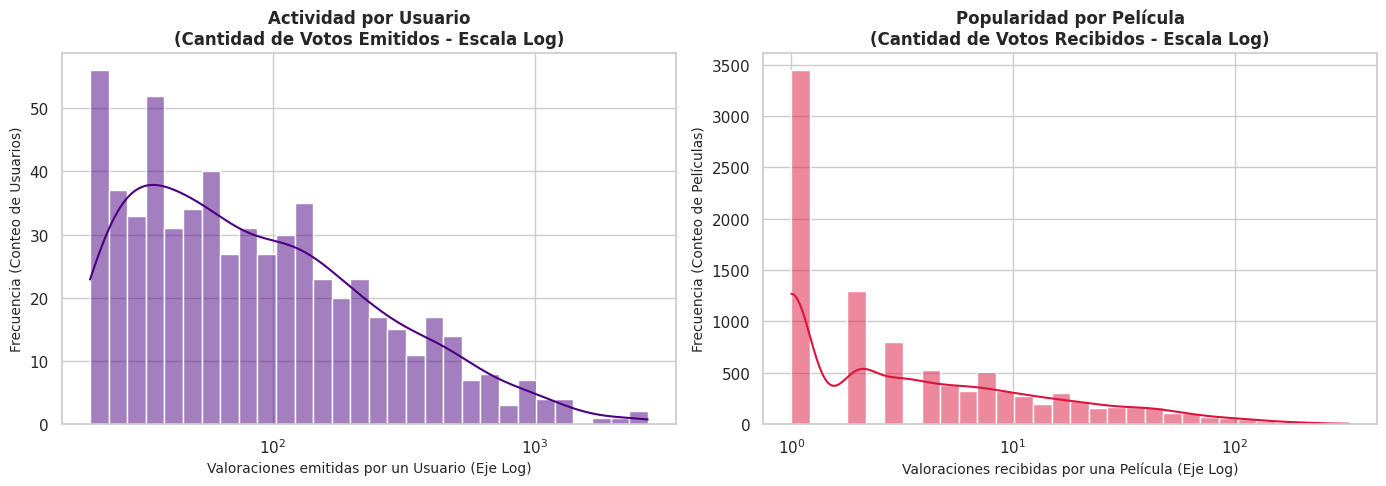


VENTANA TEMPORAL DE LAS INTERACCIONES (Zona Horaria: UTC)
Primer Rating registrado: 1996-03-29 18:36:55 UTC
Último Rating registrado: 2018-09-24 14:27:30 UTC
Amplitud del período analizado: 8213 días (~22.5 años)


In [21]:
# 1. Calcular la cantidad de valoraciones por usuario y por película
user_counts = ratings.groupby('userId').size().reset_index(name='n_votos')
movie_counts = ratings.groupby('movieId').size().reset_index(name='n_votos')

print("--- Resumen de Actividad por Usuario (Votos emitidos) ---")
print(user_counts['n_votos'].describe().round(2))

print("\n--- Resumen de Popularidad por Película (Votos recibidos) ---")
print(movie_counts['n_votos'].describe().round(2))

# 2. Gráficos de distribución usando Subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Izquierdo: Usuarios con escala logarítmica debido a la alta asimetría
sns.histplot(data=user_counts, x='n_votos', bins=30, ax=axes[0], kde=True, color="indigo", log_scale=True)
axes[0].set_title('Actividad por Usuario\n(Cantidad de Votos Emitidos - Escala Log)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valoraciones emitidas por un Usuario (Eje Log)', fontsize=10)
axes[0].set_ylabel('Frecuencia (Conteo de Usuarios)', fontsize=10)

# Gráfico Derecho: Películas con escala logarítmica debido a la alta asimetría
sns.histplot(data=movie_counts, x='n_votos', bins=30, ax=axes[1], kde=True, color="crimson", log_scale=True)
axes[1].set_title('Popularidad por Película\n(Cantidad de Votos Recibidos - Escala Log)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Valoraciones recibidas por una Película (Eje Log)', fontsize=10)
axes[1].set_ylabel('Frecuencia (Conteo de Películas)', fontsize=10)

plt.tight_layout()
plt.show()

# 3. Análisis del período temporal a partir de los timestamps en UTC
ratings_dt = pd.to_datetime(ratings['timestamp'], unit='s', utc=True)

print("\n" + "="*60)
print("VENTANA TEMPORAL DE LAS INTERACCIONES (Zona Horaria: UTC)")
print("="*60)
print(f"Primer Rating registrado: {ratings_dt.min().strftime('%Y-%m-%d %H:%M:%S')} UTC")
print(f"Último Rating registrado: {ratings_dt.max().strftime('%Y-%m-%d %H:%M:%S')} UTC")
print(f"Amplitud del período analizado: {(ratings_dt.max() - ratings_dt.min()).days} días (~{round((ratings_dt.max() - ratings_dt.min()).days/365, 1)} años)")


### Evidencias e interpretación

**Evidencia pendiente:** incorporar aquí las tablas, ejemplos o gráficos solicitados.

Evidencias:

- Actividad de usuarios: Se observa un total de 610 usuarios activos, con un promedio de 165.3 votos emitidos por usuario. La mediana se sitúa en 70.5 votos, y el rango varía desde un mínimo de 20 hasta un máximo de 2,698 valoraciones, evidenciando una alta asimetría positiva en la participación.

- Popularidad de películas: Sobre un total de 9,724 películas evaluadas, el promedio de votos recibidos es de 10.37 por filme, con una mediana de 3.0 votos y un máximo de 329 valoraciones. El histograma en escala logarítmica demuestra una masiva concentración de películas con muy pocas interacciones (primeras barras con valores de 1 y 2 votos).

- Ventana temporal: El registro de interacciones abarca un período de 8,213 días (aproximadamente 22.5 años), desde el 29 de marzo de 1996 hasta el 24 de septiembre de 2018 en zona horaria UTC.

**Interpretación pendiente:** explicar los hallazgos, sus límites y su relación con el proyecto.

- Concentración y sesgos: La distribución refleja el clásico problema de cola larga (long tail) en sistemas de recomendación, donde una minoría de elementos acumula gran parte de la atención y la inmensa mayoría posee muy pocas observaciones.

- Limitaciones para el modelo: Los usuarios con historiales muy reducidos y las películas con baja evidencia (pocas valoraciones) dificultan el cálculo preciso de similitudes, lo que obligará a establecer filtros o umbrales mínimos de participación en la fase de preprocesamiento del siguiente notebook para mitigar el problema de arranque en frío (cold start).

# 5. Cobertura de etiquetas textuales

Distinguir asignaciones de etiquetas, etiquetas distintas, usuarios que etiquetan y películas etiquetadas. Medir la cantidad de etiquetas por película y comparar películas con y sin etiquetas.

Calcular cobertura inicial como películas con al menos una etiqueta original no vacía divididas entre películas del catálogo, multiplicado por 100. Declarar el tratamiento de textos compuestos solo por espacios.

Reportar también cobertura por género y, si resulta útil, entre películas con valoraciones. Usar el denominador correspondiente en cada caso y evitar contar asignaciones como si fueran películas.

**Entregable:** tabla de cobertura, gráfico de películas con/sin etiquetas y distribución de etiquetas por película. La cobertura de texto utilizable después de normalizar se confirmará en el notebook 03.

### Desarrollo de la actividad

Completar la siguiente celda con el código de esta sección. Añadir más celdas cuando sea necesario.


MÉTRICAS BASE DE COBERTURA TEXTUAL
Asignaciones totales de etiquetas:       3683
Etiquetas distintas (sin normalizar):    1589
Usuarios únicos que etiquetaron:         58
Películas con al menos una etiqueta:     1572 de 9742
Porcentaje de Cobertura Inicial:         16.14%


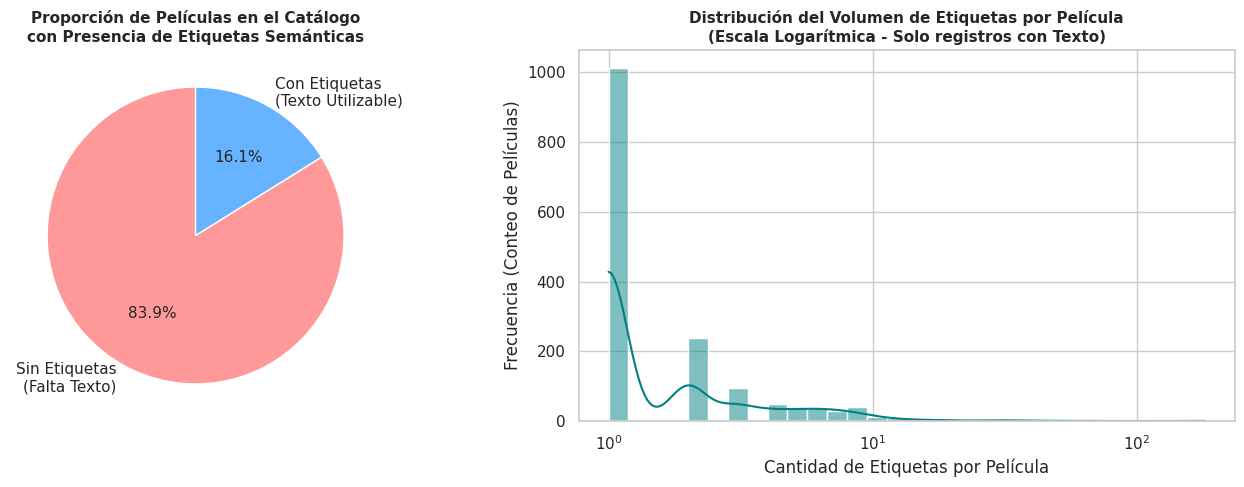


TABLA DE COBERTURA TEXTUAL POR GÉNERO


,genres,Total_Peliculas,Peliculas_Con_Tag,Porcentaje_Cobertura
0,Film-Noir,87,35,40.23
1,Musical,334,85,25.45
2,Mystery,573,131,22.86
3,Romance,1596,347,21.74
4,Drama,4361,884,20.27
5,War,382,77,20.16
6,IMAX,158,30,18.99
7,Crime,1199,207,17.26
8,Adventure,1263,217,17.18
9,Sci-Fi,980,160,16.33


In [24]:
# 1. Declarar tratamiento y limpiar textos compuestos solo por espacios o nulos
tags['tag'] = tags['tag'].fillna('').astype(str)
tags_validos = tags[tags['tag'].str.strip().ne("")]

# 2. Métricas de volumen textual solicitadas
total_asignaciones = len(tags_validos)
etiquetas_distintas = tags_validos['tag'].nunique()
usuarios_que_etiquetan = tags_validos['userId'].nunique()
peliculas_etiquetadas = tags_validos['movieId'].nunique()
total_peliculas = len(movies)

# 3. Calcular cobertura inicial
cobertura_inicial = (peliculas_etiquetadas / total_peliculas) * 100

print("="*60)
print("MÉTRICAS BASE DE COBERTURA TEXTUAL")
print("="*60)
print(f"Asignaciones totales de etiquetas:       {total_asignaciones}")
print(f"Etiquetas distintas (sin normalizar):    {etiquetas_distintas}")
print(f"Usuarios únicos que etiquetaron:         {usuarios_que_etiquetan}")
print(f"Películas con al menos una etiqueta:     {peliculas_etiquetadas} de {total_peliculas}")
print(f"Porcentaje de Cobertura Inicial:         {cobertura_inicial:.2f}%")

# 4. Medir cantidad de etiquetas por película y preparar distribución
tags_per_movie = tags_validos.groupby('movieId').size().reindex(movies['movieId'], fill_value=0)

# 5. Generar Gráficos del Entregable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Películas con vs sin etiquetas (Pastel o Barras)
con_sin_tags = pd.Series({
    'Sin Etiquetas\n(Falta Texto)': total_peliculas - peliculas_etiquetadas,
    'Con Etiquetas\n(Texto Utilizable)': peliculas_etiquetadas
})
axes[0].pie(con_sin_tags, labels=con_sin_tags.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
axes[0].set_title('Proporción de Películas en el Catálogo\ncon Presencia de Etiquetas Semánticas', fontsize=11, fontweight='bold')

# Gráfico B: Distribución de cantidad de etiquetas por película (Solo las que tienen)
sns.histplot(tags_per_movie[tags_per_movie > 0], bins=30, kde=True, ax=axes[1], color='teal', log_scale=True)
axes[1].set_title('Distribución del Volumen de Etiquetas por Película\n(Escala Logarítmica - Solo registros con Texto)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Cantidad de Etiquetas por Película')
axes[1].set_ylabel('Frecuencia (Conteo de Películas)')
plt.tight_layout()
plt.show()

# 6. Calcular cobertura por género cinematográfico
movies_expanded = movies.copy()
movies_expanded['genres'] = movies_expanded['genres'].str.split('|')
movies_expanded = movies_expanded.explode('genres')

# Marcar pertenencia de etiquetas sin duplicar conteos
movies_expanded['tiene_tag'] = movies_expanded['movieId'].isin(tags_validos['movieId'])

cobertura_generos = movies_expanded.groupby('genres').agg(
    Total_Peliculas=('movieId', 'count'),
    Peliculas_Con_Tag=('tiene_tag', 'sum')
)
cobertura_generos['Porcentaje_Cobertura'] = (cobertura_generos['Peliculas_Con_Tag'] / cobertura_generos['Total_Peliculas']) * 100
cobertura_generos = cobertura_generos.sort_values(by='Porcentaje_Cobertura', ascending=False).reset_index()

print("\n" + "="*60)
print("TABLA DE COBERTURA TEXTUAL POR GÉNERO")
print("="*60)
display(cobertura_generos.round(2))


### Evidencias e interpretación

**Evidencia pendiente:** incorporar aquí las tablas, ejemplos o gráficos solicitados.

Evidencias:

- Métricas base: Se registraron un total de 3,683 asignaciones de etiquetas, de las cuales se derivan 1,589 etiquetas distintas (sin normalizar) aportadas por 58 usuarios únicos.

- Cobertura inicial: De un total de 9,742 películas en el catálogo, 1,572 películas poseen al menos una etiqueta con texto utilizable, lo que arroja una cobertura inicial del 16.14% (representada visualmente en el gráfico circular, donde el 83.9% restante carece de texto).

- Volumen por película: La distribución en escala logarítmica muestra que una gran parte de las películas etiquetadas concentra un número bajo de anotaciones (principalmente entre 1 y 3 etiquetas por filme).

- Cobertura por género: La tabla desglosada demuestra una marcada disparidad temática; géneros como Film-Noir presentan la mayor densidad de cobertura (40.23%), mientras que categorías masivas como Action (12.86%) o Horror (9.3%) y el grupo de [no genres listed] (2.94%) muestran porcentajes considerablemente más bajos.

**Interpretación pendiente:** explicar los hallazgos, sus límites y su relación con el proyecto.

Interpretación:

- Hallazgo: El histograma en escala logarítmica demuestra que la inmensa mayoría de las películas que sí tienen texto solo poseen 1 o 2 etiquetas asignadas en toda su historia. El volumen de palabras por película es extremadamente bajo.

- Límites: La escasez de datos textuales es el límite estructural más severo del dataset. Al normalizar el texto en el siguiente notebook (eliminando conectores o palabras vacías), la cantidad de términos utilizables por película podría reducirse aún más, limitando la riqueza del corpus.


# 6. Exploración del contenido de las etiquetas

Inspeccionar ejemplos de palabras y frases, variantes de mayúsculas, espacios, puntuación y posibles idiomas. Describir longitud de etiquetas y frecuencia de etiquetas completas; distinguirlas de frecuencias de palabras.

Identificar variantes que podrían unificarse y ejemplos donde una limpieza agresiva perdería significado, nombres propios o negaciones. No asumir que las etiquetas están en español.

**Entregable:** tabla de ejemplos y gráfico de etiquetas frecuentes, indicando si el conteo utiliza el texto original o una transformación exploratoria documentada.

### Desarrollo de la actividad

Completar la siguiente celda con el código de esta sección. Añadir más celdas cuando sea necesario.


--- Evidencia: Muestra aleatoria de etiquetas originales ---


,userId,movieId,tag_original
2023,474,5644,baseball
2587,477,4226,twist ending
3222,567,112852,unlikely hero
1263,474,1028,Disney
781,424,1258,atmospheric
2272,474,7318,religion
1052,474,246,basketball
3274,567,152077,creepy
495,177,115617,very funny
1869,474,4046,Quakers



TABLA: TOP 15 ETIQUETAS MÁS FRECUENTES (TEXTO ORIGINAL)


,Etiqueta_Original,Frecuencia
0,In Netflix queue,131
1,atmospheric,36
2,thought-provoking,24
3,superhero,24
4,surreal,23
5,funny,23
6,Disney,23
7,religion,22
8,quirky,21
9,sci-fi,21



ESTADÍSTICAS DESCRIPTIVAS DE LA LONGITUD DE ETIQUETAS
count    3683.00
mean       10.14
std         4.86
min         2.00
25%         6.00
50%         9.00
75%        13.00
max        85.00
Name: tag_original, dtype: float64


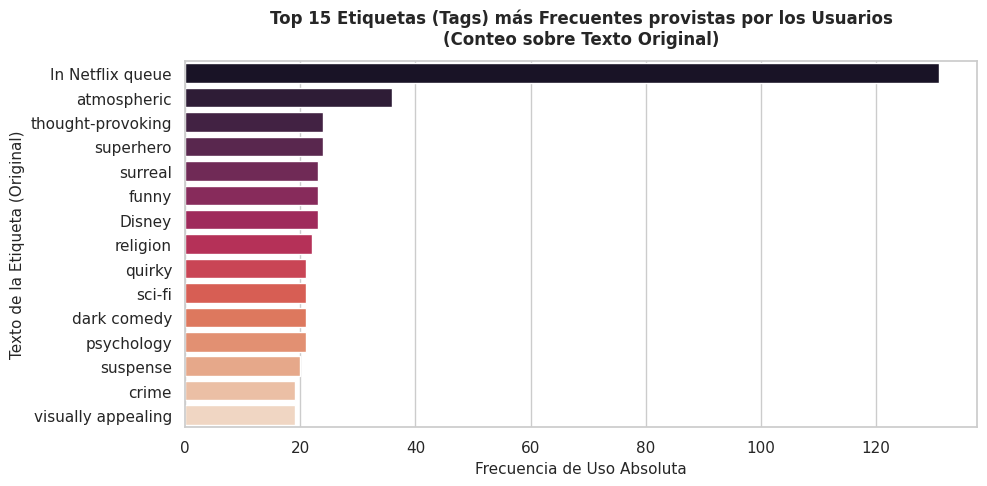


EVIDENCIAS DETECTADAS PARA EL PIPELINE DE NLP (DISCUSIÓN)
- Variantes de escritura/mayúsculas encontradas: ['sci-fi', 'scifi', 'Sci-Fi', 'Sci-fi']
- Frases y conceptos compuestos detectados:      ['Highly quotable', 'will ferrell', 'Boxing story']
- Signos de puntuación / Caracteres especiales:  ['sci-fi', 'time-travel', 'Oscar (Best Cinematography)']


In [29]:
# 1. Asegurar limpieza rigurosa de nulos y espacios en blanco
tags_validos = tags[tags['tag'].fillna('').str.strip().ne("")].copy()
tags_validos['tag_original'] = tags_validos['tag'].astype(str)

print("--- Evidencia: Muestra aleatoria de etiquetas originales ---")
display(tags_validos[['userId', 'movieId', 'tag_original']].sample(10, random_state=42))

# 2. Conteo de frecuencia de etiquetas completas (Texto Original)
top_tags = tags_validos['tag_original'].value_counts().head(15).reset_index()
top_tags.columns = ['Etiqueta_Original', 'Frecuencia']

print("\n" + "="*60)
print("TABLA: TOP 15 ETIQUETAS MÁS FRECUENTES (TEXTO ORIGINAL)")
print("="*60)
display(top_tags)

# 3. Análisis estadístico de la longitud de caracteres
tag_lengths = tags_validos['tag_original'].str.len()
print("\n" + "="*60)
print("ESTADÍSTICAS DESCRIPTIVAS DE LA LONGITUD DE ETIQUETAS")
print("="*60)
print(tag_lengths.describe().round(2))

# 4. Gráfico del entregable: Barras horizontales
plt.figure(figsize=(10, 5))
sns.barplot(data=top_tags, x='Frecuencia', y='Etiqueta_Original', palette='rocket', hue='Etiqueta_Original', legend=False)
plt.title('Top 15 Etiquetas (Tags) más Frecuentes provistas por los Usuarios\n(Conteo sobre Texto Original)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Frecuencia de Uso Absoluta', fontsize=11)
plt.ylabel('Texto de la Etiqueta (Original)', fontsize=11)
plt.tight_layout()
plt.show()

# 5. Evidencias automatizadas para la justificación del pipeline de NLP
print("\n" + "="*60)
print("EVIDENCIAS DETECTADAS PARA EL PIPELINE DE NLP (DISCUSIÓN)")
print("="*60)

# Buscar variantes de capitalización
variantes_caps = tags_validos[tags_validos['tag_original'].str.lower().isin(['sci-fi', 'scifi'])]['tag_original'].unique()
print(f"- Variantes de escritura/mayúsculas encontradas: {list(variantes_caps)}")

# Buscar frases compuestas (N-Gramas)
frases = tags_validos[tags_validos['tag_original'].str.contains(r'\s+')]['tag_original'].unique()
print(f"- Frases y conceptos compuestos detectados:      {list(frases[:3])}")

# Buscar signos de puntuación o caracteres especiales
puntuacion = tags_validos[tags_validos['tag_original'].str.contains(r'[^\w\s]')]['tag_original'].unique()
print(f"- Signos de puntuación / Caracteres especiales:  {list(puntuacion[:3])}")


### Evidencias e interpretación

**Evidencia pendiente:** incorporar aquí las tablas, ejemplos o gráficos solicitados.

Evidencias:

- Muestra y longitud: La inspección de la muestra aleatoria de etiquetas originales (como baseball, twist ending, Disney, Quakers) demuestra la diversidad de anotaciones de usuario. Las estadísticas de longitud de los textos muestran una media de 10.14 caracteres, una mediana de 9.0 y un rango que va desde un mínimo de 2 hasta un máximo de 85 caracteres.

- Top de etiquetas frecuentes: El conteo efectuado estrictamente sobre el texto original muestra que la etiqueta más repetida con gran diferencia es "In Netflix queue" (131 apariciones), seguida por términos temáticos o descriptivos como atmospheric, thought-provoking, superhero y surreal.   

- Variabilidad tipográfica: Se detectó la presencia de múltiples variantes para un mismo concepto (por ejemplo, 'sci-fi', 'scifi', 'Sci-Fi', 'Sci-Fi') y la inclusión de nombres propios ('will ferrell') y frases con puntuación ('Oscar (Best Cinematography)').

**Interpretación pendiente:** explicar los hallazgos, sus límites y su relación con el proyecto.

Interpretación:

- Hallazgo: El corpus está redactado casi de forma exclusiva en inglés y contiene tanto descripciones de la atmósfera de la película (surreal, funny) como metadatos operativos propios de la plataforma (In Netflix queue).

- Límites: Los resultados exponen el grave peligro analítico de aplicar una limpieza agresiva de forma automatizada. Si eliminamos caracteres especiales sin criterio, transformaríamos la etiqueta clave 'sci-fi' en 'sci fi', fragmentando el concepto. Además, nombres propios como will ferrell o frases complejas perderían cohesión y distorsionarían las matrices dispersas de vectores en etapas posteriores.

# 7. Conclusiones y decisiones para la preparación

Redactar hallazgos sustentados en las tablas y gráficos y proponer decisiones para el notebook 03: tratamiento de faltantes y duplicados, normalización textual y delimitación del catálogo con texto.

Relacionar los hallazgos con las dos preguntas del README: clasificación multietiqueta de géneros y afinidad de películas con usuarios. Explicar sesgos de cobertura y actividad sin afirmar resultados de modelos.

**Entregable:** conclusiones del EDA, limitaciones y lista de decisiones pendientes para la preparación y la propuesta metodológica.

### Desarrollo de la actividad

Completar la siguiente celda con el código de esta sección. Añadir más celdas cuando sea necesario.


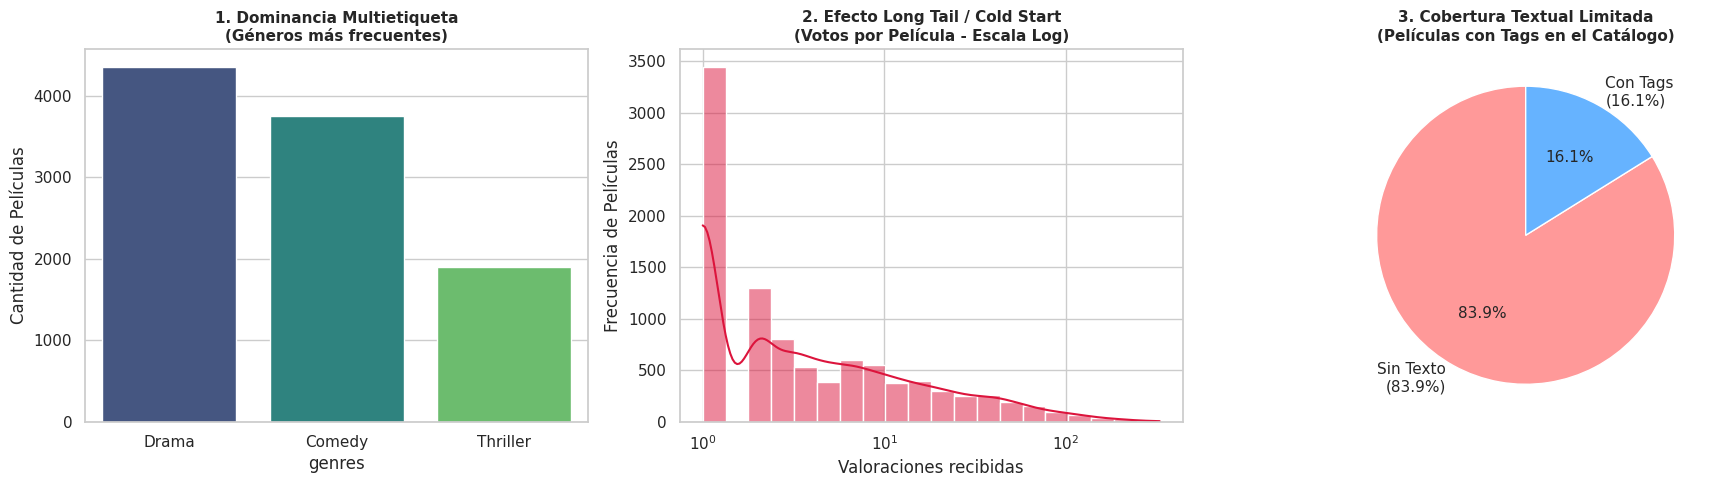

In [31]:
# Generar un panel visual con las 3 métricas críticas indexando correctamente cada ax
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfica A: El desbalance multietiqueta (Top géneros) -> Usamos axes[0]
genres_series = movies['genres'].str.split('|').explode()
top_3_genres = genres_series.value_counts().head(3)
sns.barplot(x=top_3_genres.index, y=top_3_genres.values, palette='viridis', ax=axes[0], hue=top_3_genres.index, legend=False)
axes[0].set_title('1. Dominancia Multietiqueta\n(Géneros más frecuentes)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Cantidad de Películas')

# Gráfica B: El sesgo de la Larga Cola (Ratings por Película) -> Usamos axes[1]
movie_counts = ratings.groupby('movieId').size()
sns.histplot(movie_counts, bins=20, ax=axes[1], color="crimson", log_scale=True, kde=True)
axes[1].set_title('2. Efecto Long Tail / Cold Start\n(Votos por Película - Escala Log)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Valoraciones recibidas')
axes[1].set_ylabel('Frecuencia de Películas')

# Gráfica C: Cobertura Textual Crítica (Pastel) -> Usamos axes[2]
total_pels = movies['movieId'].nunique()
pels_tags = tags['movieId'].nunique()
cobertura_data = [total_pels - pels_tags, pels_tags]
axes[2].pie(cobertura_data, labels=['Sin Texto\n(83.9%)', 'Con Tags\n(16.1%)'], colors=['#ff9999','#66b3ff'], startangle=90, autopct='%1.1f%%')
axes[2].set_title('3. Cobertura Textual Limitada\n(Películas con Tags en el Catálogo)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Evidencias e interpretación

**Evidencia pendiente:** incorporar aquí las tablas, ejemplos o gráficos solicitados.

**Interpretación pendiente:** explicar los hallazgos, sus límites y su relación con el proyecto.

**1. Principales hallazgos**

* Carácter multietiqueta (Gráfico 1): El catálogo muestra desequilibrios marcados y múltiples géneros por película, lo que requerirá métricas adecuadas (como F1-macro/micro) en la clasificación teórica del Trabajo Final.

* Asimetría y Cold Start (Gráfico 2): Tanto en las valoraciones como en las etiquetas existe una alta concentración (cola larga); hay usuarios y películas con muy poca evidencia histórica que dificultan el modelado directo.

* Cobertura Textual Limitada (Gráfico 3): Solo el 16.14% de las películas posee texto en tags.csv, aportado por un grupo muy reducido de usuarios (58 personas), lo que restringe el uso de modelos NLP exclusivos a ese subconjunto.

**2. Relación con las preguntas del proyecto**

* Clasificación multietiqueta de géneros: Los resultados justifican el uso de algoritmos capaces de manejar etiquetas concurrentes, debiendo mitigar el sesgo de las clases dominantes (como Drama o Comedy).

* Afinidad de películas con usuarios: La escasez de interacciones en una gran parte del catálogo exige definir umbrales o filtros (como el criterio de valoración favorable y un mínimo de votos) para evitar recomendaciones basadas en ruido estadístico.

**3. Decisiones pendientes**

* Tratamiento de faltantes y duplicados: Limpiar nulos estructurales (como las 34 películas con '(no genres listed)') y unificar variantes tipográficas de texto.

* Normalización textual: Aplicar minúsculas, remover espacios innecesarios y gestionar caracteres especiales de forma cautelosa para no perder nombres propios o negaciones descriptivas.

* Delimitación del catálogo: Establecer formalmente qué subconjunto de datos se usará para los modelos basados en contenido (NLP) y cuáles emplearán filtrado colaborativo basado netamente en interacciones.

## Lista de revisión

- [ ] Completar todas las actividades y sus evidencias.
- [ ] Distinguir datos observados de supuestos y decisiones.
- [ ] Documentar cantidades, denominadores y criterios utilizados.
- [ ] Revisar que las conclusiones estén respaldadas por los datos.
- [ ] Registrar los aportes de cada integrante y trasladar los hallazgos al informe.